# MultiSample Model

This notebook is an experiment to combine different samples to extract a meaningful embedding from combining those two samples

In [46]:
import os
import numpy as np
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import importlib
import SpatialGlue
importlib.reload(SpatialGlue)

from SpatialGlue import SpatialGlueMini, train_model

import random
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Helpers


In [47]:
# a KNN helper
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = nbrs.kneighbors(X)

    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index

In [48]:
# helper to offset indices when merging graphs
def offset_edge_index(edge_index, offset):
    return edge_index + offset

# Data Preprocessing

Here we will load two different lymoh node samples and preprocess each sample to aquire both the spatil coordinates and features from each sample

In [49]:
# Load Data
adata_rna_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195494_A1_LN.h5ad")
adata_prot_A1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195498_A1_LN_Protein.h5ad")


adata_rna_D1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195496_D1_LN.h5ad")
adata_prot_D1 = sc.read_h5ad("../Data/GSE263617_RAW//GSM8195500_D1_LN_Protein.h5ad")

In [50]:
# Align spots within each sample
common_A1 = adata_rna_A1.obs_names.intersection(adata_prot_A1.obs_names)
adata_rna_A1 = adata_rna_A1[common_A1].copy()
adata_prot_A1 = adata_prot_A1[common_A1].copy()
assert all(adata_rna_A1.obs_names == adata_prot_A1.obs_names)

common_D1 = adata_rna_D1.obs_names.intersection(adata_prot_D1.obs_names)
adata_rna_D1 = adata_rna_D1[common_D1].copy()
adata_prot_D1 = adata_prot_D1[common_D1].copy()
assert all(adata_rna_D1.obs_names == adata_prot_D1.obs_names)

In [51]:
# Extract processed features and coordinates
X_rna_A1 = adata_rna_A1.obsm["feat"].astype(np.float32)
X_prot_A1 = adata_prot_A1.obsm["feat"].astype(np.float32)
coords_A1 = adata_rna_A1.obsm["spatial"].astype(np.float32)

X_rna_D1 = adata_rna_D1.obsm["feat"].astype(np.float32)
X_prot_D1 = adata_prot_D1.obsm["feat"].astype(np.float32)
coords_D1 = adata_rna_D1.obsm["spatial"].astype(np.float32)

print("A1 RNA:", X_rna_A1.shape)
print("A1 Protein:", X_prot_A1.shape)
print("A1 coords:", coords_A1.shape)

print("D1 RNA:", X_rna_D1.shape)
print("D1 Protein:", X_prot_D1.shape)
print("D1 coords:", coords_D1.shape)

#Create Sample Labels
sample_ids_A1 = np.zeros(X_rna_A1.shape[0], dtype=np.int64)
sample_ids_D1 = np.ones(X_rna_D1.shape[0], dtype=np.int64)

sample_names = (
    ["A1_LN"] * X_rna_A1.shape[0] +
    ["D1_LN"] * X_rna_D1.shape[0]
)
sample_names = np.array(sample_names)

A1 RNA: (3484, 30)
A1 Protein: (3484, 30)
A1 coords: (3484, 2)
D1 RNA: (3359, 30)
D1 Protein: (3359, 30)
D1 coords: (3359, 2)


In [52]:
#Combine features for future plotting
X_rna_all = np.concatenate([X_rna_A1, X_rna_D1], axis=0)
X_prot_all = np.concatenate([X_prot_A1, X_prot_D1], axis=0)
sample_ids = np.concatenate([sample_ids_A1, sample_ids_D1], axis=0)

print("Combined RNA:", X_rna_all.shape)
print("Combined Protein:", X_prot_all.shape)
print("Combined sample_ids:", sample_ids.shape)

Combined RNA: (6843, 30)
Combined Protein: (6843, 30)
Combined sample_ids: (6843,)


# Building Graphs for each smaple

In [53]:
# Spatial graphs
spatial_A1 = knn_edge_index(coords_A1, k=3)
spatial_D1 = knn_edge_index(coords_D1, k=3)

In [54]:
# Feature graphs
rna_feat_A1 = knn_edge_index(X_rna_A1, k=20)
rna_feat_D1 = knn_edge_index(X_rna_D1, k=20)

prot_feat_A1 = knn_edge_index(X_prot_A1, k=20)
prot_feat_D1 = knn_edge_index(X_prot_D1, k=20)

In [55]:
# Merged graphs as DISCONNECTED components
# If sample A1 has N1 spots, then every node index in D1 must be shifted by N1

N1 = X_rna_A1.shape[0]
N2 = X_rna_D1.shape[0]

spatial_D1_off = offset_edge_index(spatial_D1, N1)
rna_feat_D1_off = offset_edge_index(rna_feat_D1, N1)
prot_feat_D1_off = offset_edge_index(prot_feat_D1, N1)

spatial_edge_index = torch.cat([spatial_A1, spatial_D1_off], dim=1)
rna_feature_edge_index = torch.cat([rna_feat_A1, rna_feat_D1_off], dim=1)
prot_feature_edge_index = torch.cat([prot_feat_A1, prot_feat_D1_off], dim=1)

print("Merged spatial graph:", spatial_edge_index.shape)
print("Merged RNA feature graph:", rna_feature_edge_index.shape)
print("Merged protein feature graph:", prot_feature_edge_index.shape)

Merged spatial graph: torch.Size([2, 20529])
Merged RNA feature graph: torch.Size([2, 136860])
Merged protein feature graph: torch.Size([2, 136860])


# Train models

In [56]:
# Convert features into tensors
X_rna_t = torch.tensor(X_rna_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

In [57]:
model = SpatialGlueMini(
    in_dim=30,
    hidden_dim=64,
    latent_dim=32,
    num_modalities=2,
    dropout=0.1
)

model = train_model(
    model,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    epochs=500,
    lr=1e-4,
    lambda_corr=1.0,
    device="cpu"
)

Epoch 0000 | total=11.3955 | recon=7.2284 | corr=4.1671
Epoch 0050 | total=8.8405 | recon=7.0531 | corr=1.7874
Epoch 0100 | total=8.2535 | recon=6.9318 | corr=1.3217
Epoch 0150 | total=7.8073 | recon=6.7871 | corr=1.0201
Epoch 0200 | total=7.5042 | recon=6.6448 | corr=0.8594
Epoch 0250 | total=7.2202 | recon=6.4698 | corr=0.7504
Epoch 0300 | total=6.9567 | recon=6.2649 | corr=0.6918
Epoch 0350 | total=6.6907 | recon=6.0396 | corr=0.6511
Epoch 0400 | total=6.4259 | recon=5.8025 | corr=0.6234
Epoch 0450 | total=6.1756 | recon=5.5615 | corr=0.6141


# Extract and plot results

In [58]:
# eval and extract latent embeddings
model.eval()

with torch.no_grad():
    outputs = model(
        [X_rna_t, X_prot_t],
        spatial_edge_index,
        [rna_feature_edge_index, prot_feature_edge_index]
    )

Z = outputs["z"].cpu().numpy()
print("Z shape:", Z.shape)

Z shape: (6843, 32)


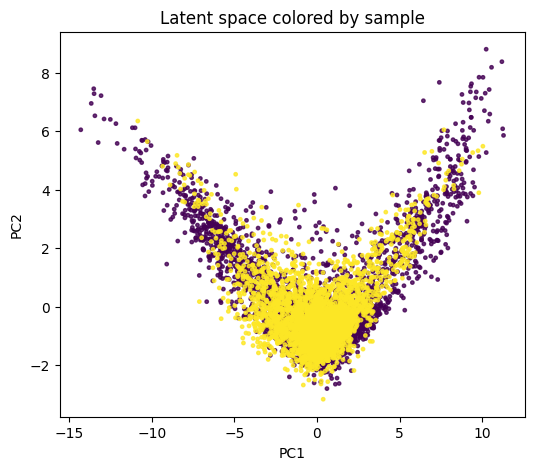

In [59]:
#plot the latents space colored by sample
pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=sample_ids, s=6, alpha=0.8)
plt.title("Latent space colored by sample")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("outputs/stage2/figures/Latentspace_colored_by_sample.png", dpi=300)
plt.show()

In [42]:
# cluster combined latent space
kmeans = KMeans(n_clusters=10, random_state=0)
labels = kmeans.fit_predict(Z)

#split results back by sample for spatial plotting
labels_A1 = labels[:N1]
labels_D1 = labels[N1:]

Z_A1 = Z[:N1]
Z_D1 = Z[N1:]

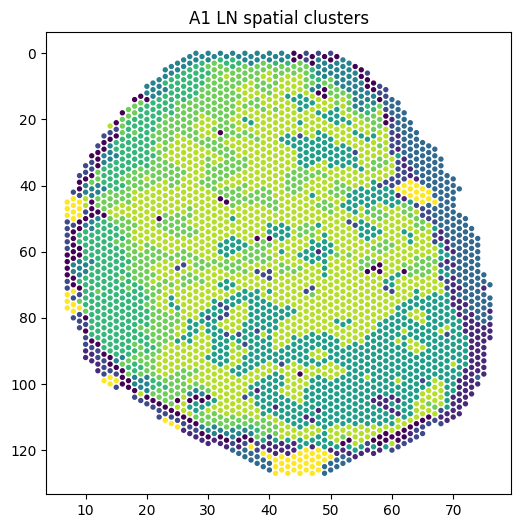

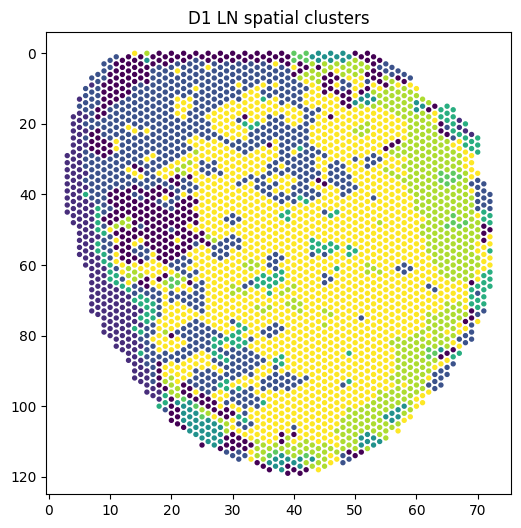

In [43]:
# plot each sample spatially
os.makedirs("outputs/stage2/figures", exist_ok=True)


plt.figure(figsize=(6, 6))
plt.scatter(coords_A1[:, 0], coords_A1[:, 1], c=labels_A1, s=8)
plt.gca().invert_yaxis()
plt.title("A1 LN spatial clusters")
plt.savefig("outputs/stage2/figures/A1_LN_spatial_clusters.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(coords_D1[:, 0], coords_D1[:, 1], c=labels_D1, s=8)
plt.gca().invert_yaxis()
plt.title("D1 LN spatial clusters")

plt.savefig("outputs/stage2/figures/D1_LN_spatial_clusters.png", dpi=300)
plt.show()

In [44]:
# save information

np.save("outputs/stage2/Z_A1_D1_LN.npy", Z)
np.save("outputs/stage2/sample_ids_A1_D1_LN.npy", sample_ids)
np.save("outputs/stage2/labels_A1_D1_LN.npy", labels)

os.makedirs("outputs/stage2/model", exist_ok=True)


torch.save(model.state_dict(), "outputs/stage2/model/model_A1_D1_LN.pt")

